Importar as bibliotecas necessárias

In [1]:
import timeit # Para medir o tempo de execução
import optuna # Para otimização de hiperparâmetros
start_time = timeit.default_timer() # Marcar o início do tempo
import torch
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
import numpy as np
from torchvision.utils import save_image
import matplotlib.pyplot as plt
# Definir o dispositivo (cuda se disponível, caso contrário CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
from scipy.stats import wasserstein_distance

import mplhep as hep
plt.style.use("default")
plt.style.use(hep.style.CMS)
plt.rcParams['font.size'] = 12 

cuda


In [2]:
def mass_func(data):
    data = torch.transpose(data, 0, 1)
    
    px = data[0] + data[1]
    py = data[2] + data[3]
    pz = data[4] + data[5]
    E = data[6] + data[7]

    m2 = E**2 - px**2 - py**2 - pz**2
    #m  = torch.sqrt(torch.clamp(m2, min=0.0))
    return m2

O próximo passo é carregar os dados de entrada. Os dados utilizados são valores de momento transversal dos píons e dos káons, partículas filha do méson D0. Inicialmente, os dados se encontram em um .txt, e devem ser transformados em um tensor no PyTorch. Além disso, os dados são normalizados para aumentar a estabilidade do treino e divididos em set de treino, validação e teste.

In [3]:
# Carregar os dados de entrada
data = np.loadtxt("data_D0_daughtersPx_Py_Pz_E_trk1_trk2.txt")
#D0_data = np.loadtxt("data_D0_daughtersPx_Py_Pz_E_D0.txt")

tensor_data_denormalized = torch.tensor(data, dtype=torch.float32, device=device)
#D0_data = torch.tensor(D0_data, dtype=torch.float32, device=device)

nVar = tensor_data_denormalized.shape[1]
mass_D0 = 1.8648

def normalize(x):
    return (x - means) / (stds + 1e-8)

def denormalize(x):
    if isinstance(x, np.ndarray):
        return x * (stds.numpy() + 1e-8) + means.numpy()
    return x * (stds + 1e-8) + means

print(f"Shape do tensor: {tensor_data_denormalized.shape}")
print(f"Raw {tensor_data_denormalized.size()}, {type(tensor_data_denormalized)}")
print(f"Dados do crus: {tensor_data_denormalized}")
print(f"Número de variáveis de entrada: {nVar}")

# Divisão dos dados em treino, validação e teste
nTotal = tensor_data_denormalized.size(0)
nTrain = int(0.6 * nTotal)
nVal = int(0.2 * nTotal)
nTest = nTotal - nTrain - nVal
print(f"nTrain: {nTrain}, nVal: {nVal}, nTest: {nTest}")

x_train_raw = tensor_data_denormalized[:nTrain]
x_val_raw   = tensor_data_denormalized[nTrain:nTrain + nVal]
x_test_raw  = tensor_data_denormalized[nTrain + nVal:]

# Estatísticas APENAS do train set
means = x_train_raw.mean(dim=0)
stds  = x_train_raw.std(dim=0)


tensor_data = normalize(tensor_data_denormalized)
# Normalizar cada split separadamente
x_train = normalize(x_train_raw)
x_val   = normalize(x_val_raw)
x_test  = normalize(x_test_raw)
tensor_data = normalize(tensor_data_denormalized)

print(f"x_train: {x_train.size()}, x_val: {x_val.size()}, x_test: {x_test.size()}")

# DataLoaders
batch_size = 64
trainloader = DataLoader(x_train, shuffle=True,  batch_size=batch_size)
valloader   = DataLoader(x_val,   shuffle=False, batch_size=batch_size)
testloader  = DataLoader(x_test,  shuffle=False, batch_size=batch_size)


x_train_phys = x_train_raw
c_train = torch.stack([
    x_train_phys[:, 0] + x_train_phys[:, 1],
    x_train_phys[:, 2] + x_train_phys[:, 3],
    x_train_phys[:, 4] + x_train_phys[:, 5],
    x_train_phys[:, 6] + x_train_phys[:, 7],
], dim=1)
c_means = c_train.mean(dim=0)
c_stds  = c_train.std(dim=0)
cVar = c_train.shape[1]

Shape do tensor: torch.Size([20000, 8])
Raw torch.Size([20000, 8]), <class 'torch.Tensor'>
Dados do crus: tensor([[ -0.1366,   2.0796,  -0.5123,  ...,  -2.2954,   0.7437,   3.7436],
        [ -1.7234,   0.1727,  -1.7169,  ...,   1.3204,   3.6637,   2.0659],
        [  1.5444,   1.7190,   0.1174,  ..., -10.7713,   4.3586,  10.9472],
        ...,
        [ -0.2093,   0.8172,  -2.9004,  ...,   0.9550,   3.3812,   1.3934],
        [ -0.6546,  -1.0264,  -0.0698,  ...,   0.2606,   0.9285,   2.1903],
        [  1.4160,   0.2751,   2.3829,  ...,  -0.0613,   5.6575,   0.6417]],
       device='cuda:0')
Número de variáveis de entrada: 8
nTrain: 12000, nVal: 4000, nTest: 4000
x_train: torch.Size([12000, 8]), x_val: torch.Size([4000, 8]), x_test: torch.Size([4000, 8])


In [4]:
def beta_annealer(epoch, n_epochs, beta_start=0.0, beta_end=0.1, warmup=20):  # https://arxiv.org/abs/1903.10145
    """
    Linear warmup: beta vai de beta_start até beta_end nas primeiras warmup epochs
    Depois mantém beta_end até o final
    """
    if epoch < warmup:
        return beta_start + (beta_end - beta_start) * (epoch / warmup)
    return beta_end

In [5]:
class PlanarFlow(nn.Module):
    def __init__(self, z_dim):
        super().__init__()
        self.w = nn.Parameter(torch.randn(z_dim))
        self.u = nn.Parameter(torch.randn(z_dim))
        self.b = nn.Parameter(torch.zeros(1))

    def forward(self, z):
        wu = (self.w @ self.u)
        u_hat = self.u + (torch.log(1 + torch.exp(wu)) - 1 - wu) * self.w / (self.w @ self.w)
        
        lin = z @ self.w + self.b          # (N,)
        h = torch.tanh(lin)
        z_new = z + u_hat * h.unsqueeze(1) # (N, z_dim)
        
        # log det jacobiano
        psi = (1 - h**2).unsqueeze(1) * self.w  # (N, z_dim)
        log_det = torch.log((1 + psi @ u_hat).abs() + 1e-8)
        return z_new, log_det

In [6]:
class VAE(nn.Module):
    def __init__(self, nVar, h_dims, z_dim, activation, n_flows):
        super().__init__()
        self.flows = nn.ModuleList([PlanarFlow(z_dim) for _ in range(n_flows)])

        # Encoder: x → z
        encoder_layers = []
        in_d = nVar  # 
        for h_dim in h_dims:
            encoder_layers.append(nn.Linear(in_d, h_dim))
            encoder_layers.append(activation())
            in_d = h_dim
        self.encoder_layers = nn.Sequential(*encoder_layers)
        self.fc_mu     = nn.Linear(in_d, z_dim)
        self.fc_logvar = nn.Linear(in_d, z_dim)

        # Decoder: z → x̂
        decoder_layers = []
        in_d = z_dim  
        for h_dim in reversed(h_dims):
            decoder_layers.append(nn.Linear(in_d, h_dim))
            decoder_layers.append(activation())
            in_d = h_dim
        self.decoder_layers = nn.Sequential(*decoder_layers)
        self.fc_out = nn.Linear(in_d, nVar)

    def encoder(self, x):
        h = self.encoder_layers(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def decoder(self, z):
        h = self.decoder_layers(z)
        return self.fc_out(h)

    def sampling(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        return mu + std * torch.randn_like(std)

    def forward(self, x):
        mu, log_var = self.encoder(x)
        
        log_var = torch.clamp(log_var, min=-10, max=10)
        
        z = self.sampling(mu, log_var)
        
        log_2pi = torch.log(torch.tensor(2 * torch.pi, device=x.device))
        log_q0  = -0.5 * torch.sum(
            log_2pi 
            + log_var 
            + (z - mu).pow(2) / torch.exp(log_var).clamp(min=1e-8),
            dim=-1
        )
        
        log_det_sum = torch.zeros(x.size(0), device=x.device)
        for flow in self.flows:
            z, log_det = flow(z)
            log_det_sum += log_det
        
        log_qk = torch.clamp(log_q0 - log_det_sum, min=-1e4, max=1e4)
        log_p  = torch.clamp(
            -0.5 * torch.sum(log_2pi + z.pow(2), dim=-1),
            min=-1e4, max=1e4
        )

        return self.decoder(z), mu, log_var, log_qk, log_p
    

def loss_function(recon_x, x, mu, log_var, beta, alpha, log_qk, log_p):

    MSE = F.mse_loss(recon_x, x, reduction='sum')
    KLD_NF = torch.sum(log_qk - log_p)               
    
    return MSE + beta * KLD_NF, MSE, KLD_NF




Treinamento e validação do modelo. Early stopping é aplicado caso a perda de validação não melhore.

In [7]:
def train(model, trainloader, optimizer, beta, alpha):
    model.train()
    train_loss = 0
    total_mse = 0
    total_kld_nf = 0

    for batch in trainloader:
        batch = batch.to(device)

        optimizer.zero_grad()
        recon_batch, mu, log_var, log_qk, log_p = model(batch)

        loss, mse, kld_nf = loss_function(recon_batch, batch, mu, log_var, beta, alpha, log_qk, log_p)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss  += loss.item()
        total_mse   += mse.item()
        total_kld_nf += kld_nf.item()

    num_batches = len(trainloader)

    return (train_loss   / num_batches,
            total_mse    / num_batches,
            total_kld_nf / num_batches)


def validate(model, valloader, beta, alpha):
    model.eval()
    val_loss = 0
    total_mse = 0
    total_kld_nf = 0

    with torch.no_grad():
        for batch in valloader:
            batch = batch.to(device)

            recon_batch, mu, log_var, log_qk, log_p = model(batch)

            loss, mse, kld_nf = loss_function(recon_batch, batch, mu, log_var, beta, alpha, log_qk, log_p)

            val_loss     += loss.item()
            total_mse    += mse.item()
            total_kld_nf += kld_nf.item()

    num_batches = len(valloader)

    return (val_loss     / num_batches,
            total_mse    / num_batches,
            total_kld_nf / num_batches)

class EarlyStopping:
    def __init__(self, patience=10, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
            return False
        elif val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            return False
        elif self.counter >= self.patience:
            return True
        self.counter += 1
        return False


Função objetivo para a otimização de hiperparâmetros com Optuna.

In [8]:
def objective(trial):
    
    # --- Hiperparâmetros ---
    n_layers = trial.suggest_int('n_layers', 2, 5)
    z_dim = trial.suggest_int('latent_dim', 4, 10)
    activation_name = trial.suggest_categorical('activation', ['relu', 'tanh', 'leaky_relu'])
    lr = trial.suggest_float('lr', 1e-5, 1e-3, log=True)
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'RMSprop'])

    #alpha = trial.suggest_float('alpha', 0.01, 1)  # 
    alpha = 0
    
    h_dims = []
    for i in range(n_layers):
        h_dims.append(trial.suggest_int(f'h_dim_{i}', 32, 256, step=32))   
    h_dims.sort(reverse=True)

    batch_size = 64
    n_flows = trial.suggest_int('n_flows', 2, 5)

    if activation_name == 'relu':
            activation_cls = nn.ReLU    
    elif activation_name == 'tanh':
        activation_cls = nn.Tanh
    else:
        activation_cls = nn.LeakyReLU 

    # DataLoaders
    trainloader = DataLoader(x_train, shuffle=True,  batch_size=batch_size)
    valloader   = DataLoader(x_val,   shuffle=False, batch_size=batch_size)

    model = VAE(nVar, h_dims, z_dim, activation_cls, n_flows).to(device)

    if optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = optim.RMSprop(model.parameters(), lr=lr)

    early_stopping = EarlyStopping(patience=10, min_delta=0.001)

    beta_end  = 0.05
    warmup    = 15
    n_epochs = 75

    for epoch in range(n_epochs):

        beta = beta_annealer(epoch, n_epochs, beta_start=0.0, beta_end=beta_end, warmup=warmup)
    
        _, _, _= train(model, trainloader, optimizer, beta, alpha)
        v_loss, _, _, = validate(model, valloader, beta, alpha)
        
        # Reportamos a v_loss (Loss Total de validação) para o Optuna
        trial.report(v_loss, epoch)
        

        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        if(epoch > warmup): 
            if early_stopping(v_loss):  # Só consideramos early stopping depois do warmup;;
                break

    return v_loss


Criar e executar o estudo de otimização de hiperparâmetros. O Optuna realiza a busca pelos melhores hiperparâmetros através de várias tentativas de treinamento. Após completar as tentativas, o melhor trial é recuperado. Os valores e parâmetros desse melhor ensaio são então impressos, mostrando o valor da função objetivo (a perda de validação) e os hiperparâmetros correspondentes que produziram o melhor desempenho do modelo.

Aqui, é inputado o número de trials desejado.

In [9]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30) 

print('Best trial:')
trial = study.best_trial
print(' Value: ', trial.value)
print(' Params: ')
for key, value in trial.params.items():
    print(f'    {key}: {value}')

[I 2026-06-19 00:08:19,330] A new study created in memory with name: no-name-46b10008-fc0f-4610-a29e-2c089c15f4d2
[W 2026-06-19 00:08:24,869] Trial 0 failed with parameters: {'n_layers': 4, 'latent_dim': 9, 'activation': 'tanh', 'lr': 7.908896241013458e-05, 'optimizer': 'RMSprop', 'h_dim_0': 128, 'h_dim_1': 64, 'h_dim_2': 256, 'h_dim_3': 256, 'n_flows': 4} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\vinic\anaconda3\envs\vaenv\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\vinic\AppData\Local\Temp\ipykernel_30844\1073349340.py", line 49, in objective
    _, _, _= train(model, trainloader, optimizer, beta, alpha)
             ~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\vinic\AppData\Local\Temp\ipykernel_30844\1776216102.py", line 11, in train
    recon_batch, mu, log_var, log_qk, log_p = model(batch)
                                

KeyboardInterrupt: 

Os melhores hiperparâmetros encontrados pelo estudo Optuna são recuperados e usados para configurar o modelo VAE. Os melhores parâmetros são extraídos do trial vencedor e utilizados para definir a função de ativação (ReLU, Tanh ou Leaky ReLU), o tamanho do batch e a arquitetura do modelo. O DataLoader é configurado novamente com o melhor tamanho de batch para os dados de treino e validação. Um novo modelo VAE é criado usando os melhores hiperparâmetros. O otimizador apropriado (Adam ou RMSprop) é configurado com a melhor taxa de aprendizado encontrada.

In [42]:
#best_params = trial.params

## THIS ONE WORK WELL (FOR REFERENCE)
best_params = {'n_layers': 3, 'latent_dim': 10, 'activation': 'leaky_relu', 'lr': 0.000513250160933866, 'optimizer': 'RMSprop', 'h_dim_0': 224, 'h_dim_1': 160, 'h_dim_2': 256, 'n_flows': 2}
best_params['alpha'] = 0  

if best_params['activation'] == 'relu':
    activation_cls = nn.ReLU
elif best_params['activation'] == 'tanh':
    activation_cls = nn.Tanh
else:
    activation_cls = nn.LeakyReLU

trainloader = DataLoader(x_train, shuffle=True,  batch_size=batch_size)
valloader   = DataLoader(x_val,   shuffle=False, batch_size=batch_size)

model = VAE(nVar, sorted([best_params[f'h_dim_{i}'] for i in range(best_params['n_layers'])], reverse=True),
            best_params['latent_dim'], activation_cls, best_params['n_flows'],).to(device)

if best_params['optimizer'] == 'Adam':
    optimizer = optim.Adam(model.parameters(), lr=best_params['lr'])
elif best_params['optimizer'] == 'RMSprop':
    optimizer = optim.RMSprop(model.parameters(), lr=best_params['lr'])

print(model)

early_stopping = EarlyStopping(patience=20, min_delta=0.001)
train_losses, val_losses = [], []

beta_end  = 0.1
warmup    = 20
n_epochs = 500

for epoch in range(n_epochs):

    beta = beta_annealer(epoch, n_epochs, beta_start=0.0, beta_end=beta_end, warmup=warmup)
    
    train_loss, train_mse, train_kld = train(model, trainloader, optimizer, beta, best_params['alpha'])
    val_loss, val_mse, val_kld = validate(model, valloader, beta, best_params['alpha'])

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    print(f"Epoch [{epoch+1}/{n_epochs}] | Loss: {train_loss:.2f} | Val Loss: {val_loss:.2f} | β={beta:.5f} | MSE: {train_mse:.2f} | KLD: {train_kld:.2f}")

    if(epoch > warmup): 
        if early_stopping(val_loss):  # Só early stopping depois do warmup do beta annealer;
            break

print('Final Train Loss:', train_loss)
print('Final Validation Loss:', val_loss)


VAE(
  (flows): ModuleList(
    (0-1): 2 x PlanarFlow()
  )
  (encoder_layers): Sequential(
    (0): Linear(in_features=8, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=256, out_features=224, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=224, out_features=160, bias=True)
    (5): LeakyReLU(negative_slope=0.01)
  )
  (fc_mu): Linear(in_features=160, out_features=10, bias=True)
  (fc_logvar): Linear(in_features=160, out_features=10, bias=True)
  (decoder_layers): Sequential(
    (0): Linear(in_features=10, out_features=160, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=160, out_features=224, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=224, out_features=256, bias=True)
    (5): LeakyReLU(negative_slope=0.01)
  )
  (fc_out): Linear(in_features=256, out_features=8, bias=True)
)
Epoch [1/500] | Loss: 156.80 | Val Loss: 85.45 | β=0.00000 | MSE

O modelo é avaliado no conjunto de teste para calcular a perda final de teste

In [43]:
# Teste final
model.eval()
test_loss = 0
with torch.no_grad():
    for batch in testloader:
        data = batch.to(device)
        recon_batch, mu, log_var, log_qk, log_p = model(data)
        loss, _, _  = loss_function(recon_batch, data, mu, log_var, beta, best_params['alpha'], log_qk, log_p)
        test_loss += loss.item()
test_loss /= len(testloader.dataset)
print('Test Loss:', test_loss)


Test Loss: 1.0634064998626709


Abaixo, se iniciam os plots. Primeiramente, temos o erro de reconstrução e KLD sendo minimizados no treinamento

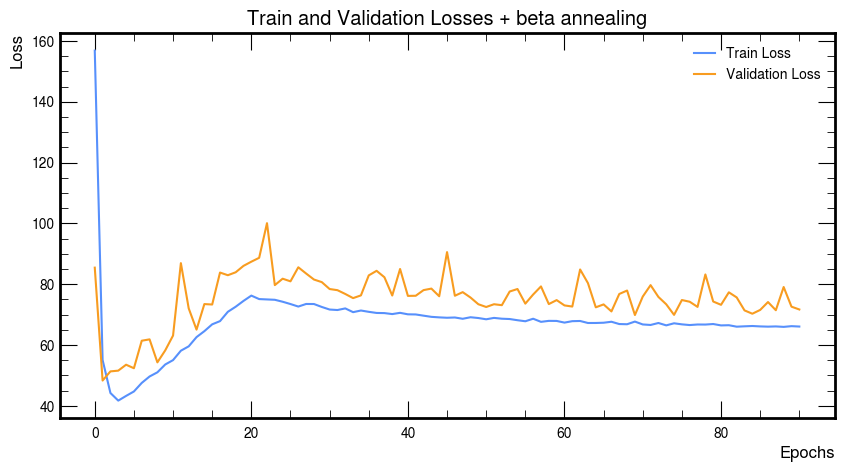

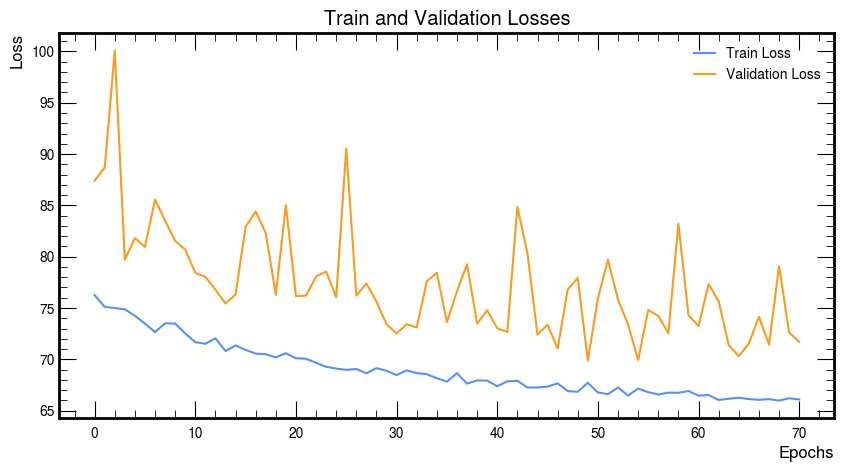

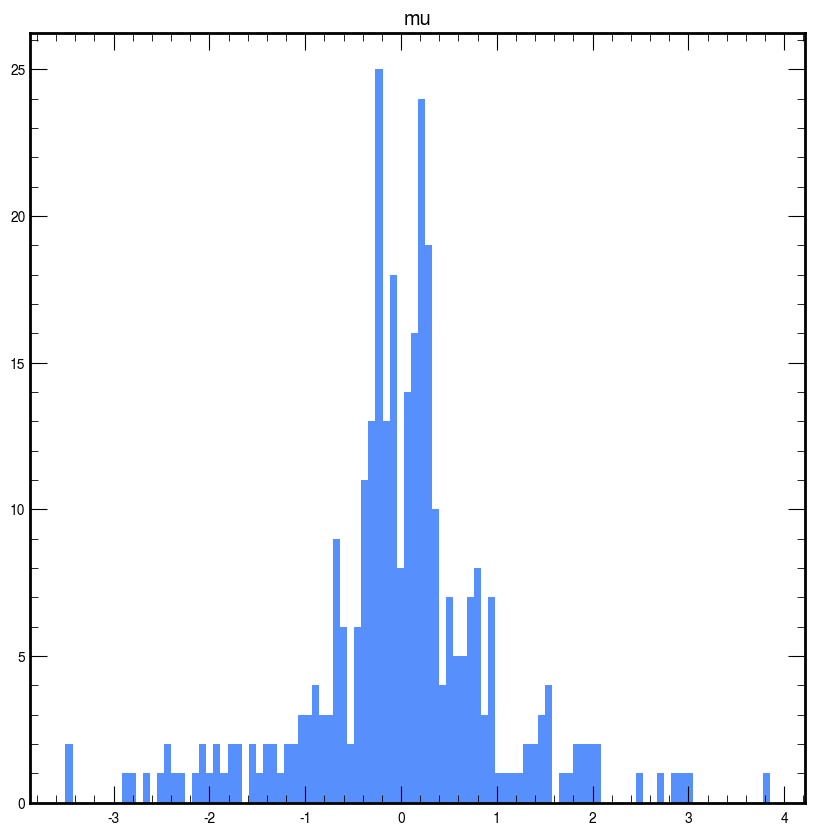

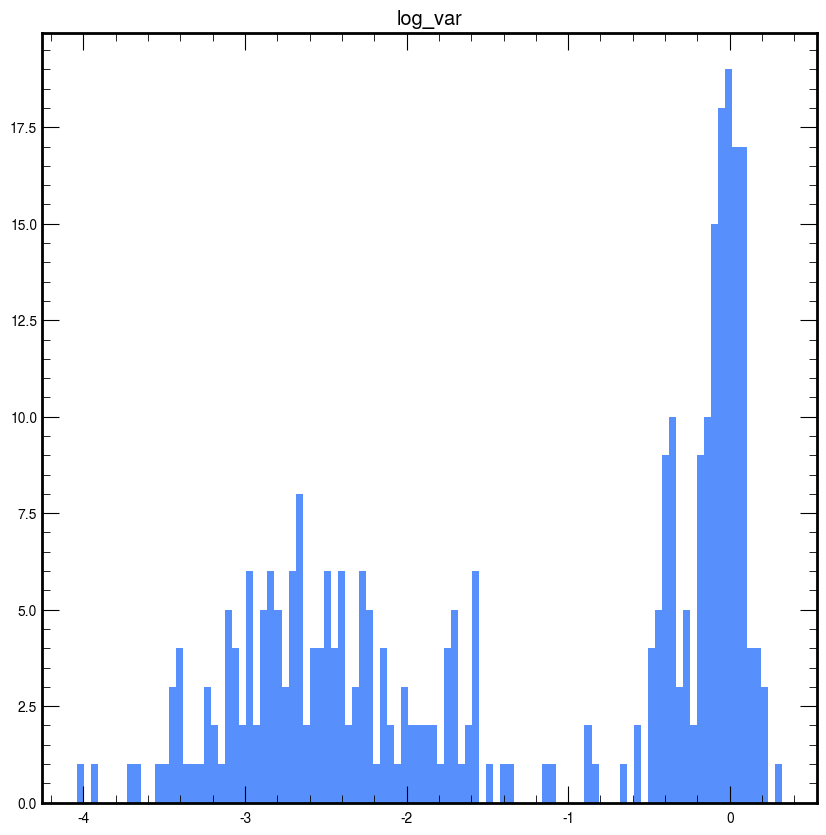

In [59]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses[:], label='Train Loss')
plt.plot(val_losses[:], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train and Validation Losses + beta annealing')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(train_losses[warmup:], label='Train Loss')
plt.plot(val_losses[warmup:], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train and Validation Losses')
plt.legend()
plt.show()

plt.hist(mu.flatten().cpu().numpy(), bins=100)
plt.title('mu')
plt.show()
plt.hist(log_var.flatten().cpu().numpy(), bins=100)
plt.title('log_var')
plt.show()



Amostra do VAE tentando reproduzir o dataset de treino (dados normalizados)

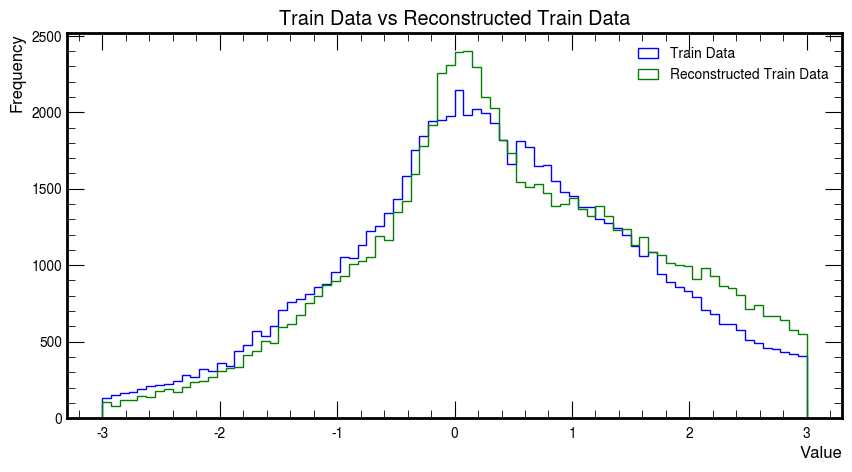

In [60]:
model.eval()
with torch.no_grad():
    recon_train, _, _, _, _ = model(x_train.float())


plt.figure(figsize=(10, 5))
plt.hist(denormalize(x_train).cpu().numpy().flatten(), bins=80, range=[-3, 3], histtype='step', color='blue', label='Train Data')
plt.hist(denormalize(recon_train).cpu().numpy().flatten(), bins=80, range=[-3, 3], histtype='step', color='green', label='Reconstructed Train Data')
plt.title('Train Data vs Reconstructed Train Data')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()


Amostra do VAE tentando reproduzir o dataset de teste (dados normalizados)

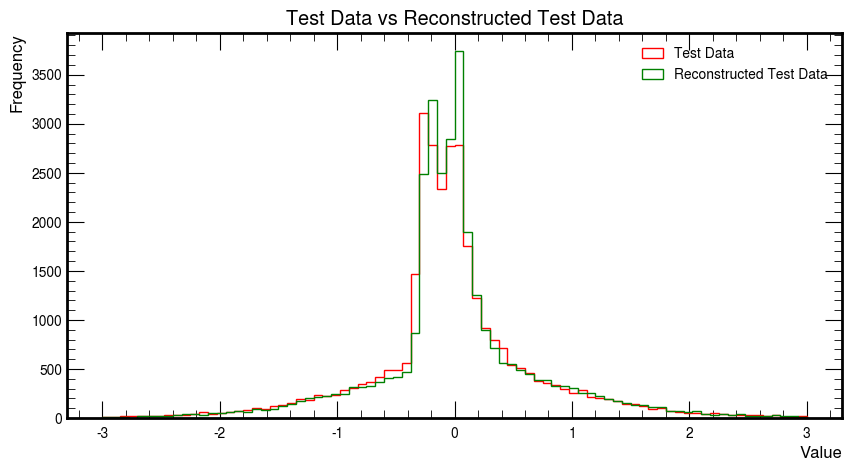

In [61]:
with torch.no_grad():
    recon_test, _, _, _, _ = model(x_test.float())

plt.figure(figsize=(10, 5))
plt.hist(x_test.cpu().numpy().flatten(), bins=80, range=[-3, 3], histtype='step', color='red', label='Test Data')
plt.hist(recon_test.cpu().numpy().flatten(), bins=80, range=[-3, 3], histtype='step', color='green', label='Reconstructed Test Data')
plt.title('Test Data vs Reconstructed Test Data')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()


Amostra do VAE tentando gerar novos dados que seguem a distribuição do input (dados normalizados)

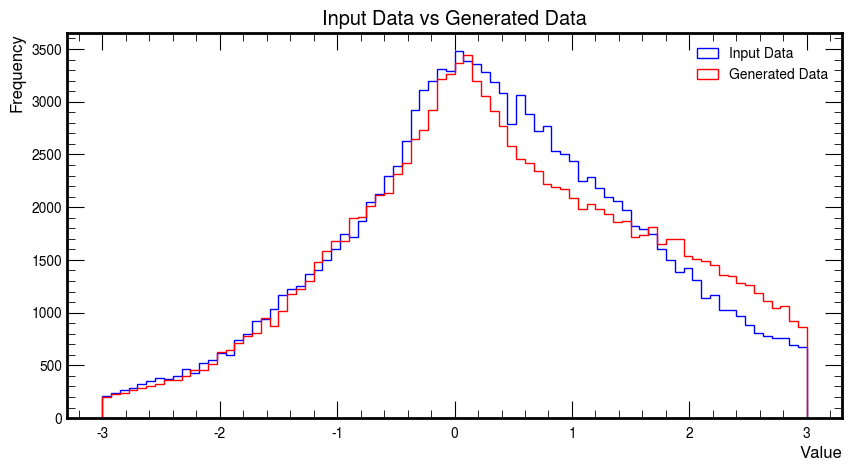

In [62]:
#with torch.no_grad():
    #z = torch.randn(tensor_data.size(0), best_params['latent_dim']).to(device)
    #generated_data = model.decoder(z)

with torch.no_grad():
    
    z = torch.randn(tensor_data.size(0), best_params['latent_dim'], device=device)
    generated_data = model.decoder(z)

plt.figure(figsize=(10, 5))
plt.hist(tensor_data_denormalized.cpu().numpy().flatten(), bins=80, range=[-3, 3], histtype='step', color='blue', label='Input Data')
plt.hist(denormalize(generated_data).cpu().numpy().flatten(), bins=80, range=[-3, 3], histtype='step', color='red', label='Generated Data')
plt.title('Input Data vs Generated Data')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()


In [63]:
import scipy.stats as stats
# Teste de Kolmogorov-Smirnov
train_recon_ks = stats.ks_2samp(x_train.cpu().numpy().flatten(), recon_train.cpu().numpy().flatten())
test_recon_ks = stats.ks_2samp(x_test.cpu().numpy().flatten(), recon_test.cpu().numpy().flatten())
input_generated_ks = stats.ks_2samp(tensor_data.cpu().numpy().flatten(), generated_data.cpu().numpy().flatten())

print(f"KS test for Train vs. Reconstructed Train: statistic={train_recon_ks.statistic}, p-value={train_recon_ks.pvalue}")
print(f"KS test for Test vs. Reconstructed Test: statistic={test_recon_ks.statistic}, p-value={test_recon_ks.pvalue}")
print(f"KS test for Input vs. Generated: statistic={input_generated_ks.statistic}, p-value={input_generated_ks.pvalue}")

KS test for Train vs. Reconstructed Train: statistic=0.057520833333333354, p-value=1.731488954126987e-138
KS test for Test vs. Reconstructed Test: statistic=0.057968749999999986, p-value=3.543024031553819e-47
KS test for Input vs. Generated: statistic=0.05346875000000001, p-value=3.180271534210507e-199


Abaixo, iremos desnormalizar os dados para gerar plots com a distribuição original, retomando a problemática da distribuição dos momentos tranversais dos píons e dos kaons.

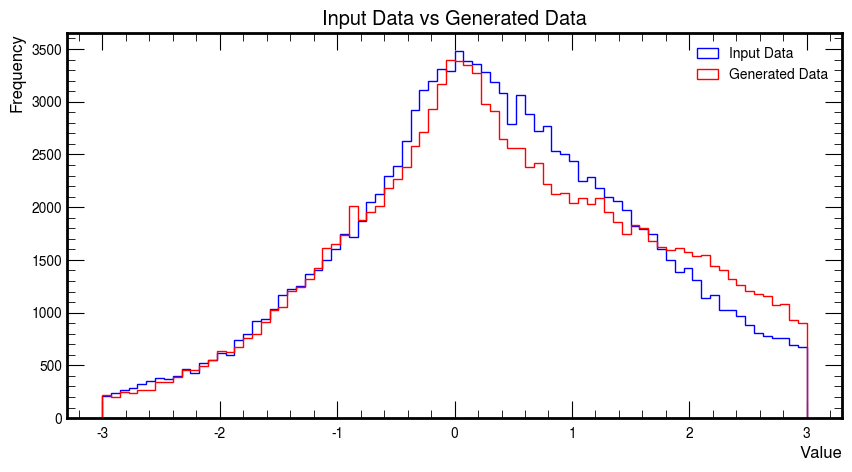

In [64]:
with torch.no_grad():

    z = torch.randn(tensor_data.size(0), best_params['latent_dim'], device=device)

    #for flow in model.flows:
    #    z, _ = flow(z)
    generated_data = model.decoder(z)

plt.figure(figsize=(10, 5))
plt.hist(tensor_data_denormalized.cpu().numpy().flatten(), bins=80, range=[-3, 3], histtype='step', color='blue', label='Input Data')
plt.hist(denormalize(generated_data).cpu().numpy().flatten(), bins=80, range=[-3, 3], histtype='step', color='red', label='Generated Data')
plt.title('Input Data vs Generated Data')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()

Amostra do VAE tentando reproduzir o dataset de treino (dados desnormalizados)

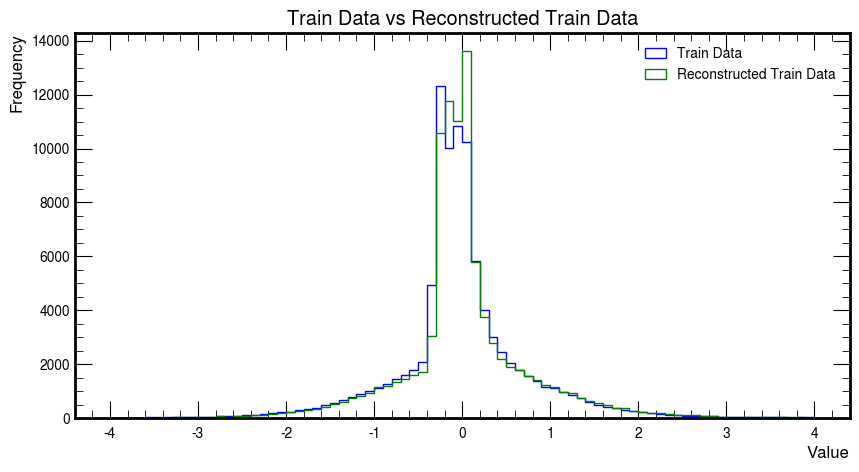

In [65]:
plt.figure(figsize=(10, 5))
plt.hist(x_train.cpu().numpy().flatten(), bins=80, range=[-4, 4], histtype='step', color='blue', label='Train Data')
plt.hist(recon_train.cpu().numpy().flatten(), bins=80, range=[-4, 4], histtype='step', color='green', label='Reconstructed Train Data')
plt.title('Train Data vs Reconstructed Train Data')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()

Amostra do VAE tentando reproduzir o dataset de teste (dados desnormalizados)

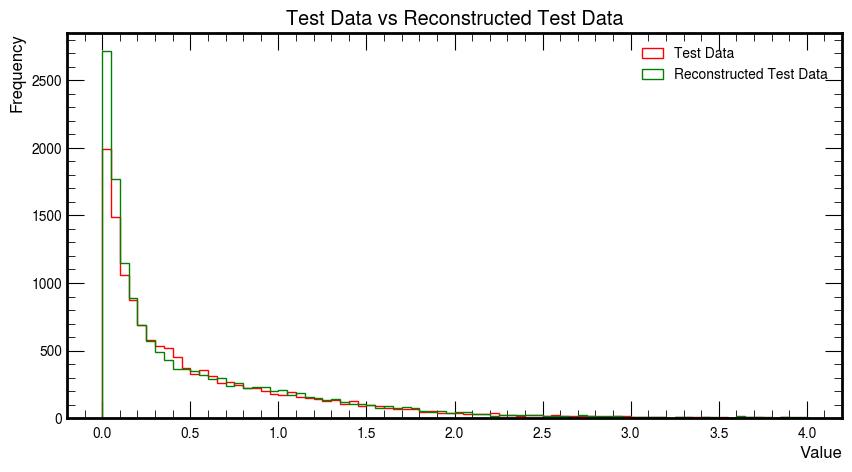

In [66]:
plt.figure(figsize=(10, 5))
plt.hist(x_test.cpu().numpy().flatten(), bins=80, range=[0, 4], histtype='step', color='red', label='Test Data')
plt.hist(recon_test.cpu().numpy().flatten(), bins=80, range=[0, 4], histtype='step', color='green', label='Reconstructed Test Data')
plt.title('Test Data vs Reconstructed Test Data')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()

Amostra do VAE tentando gerar novos dados que seguem a mesma distribuição do input (dados desnormalizados)

In [67]:
# PLOTS FUNCTION

def subplot_trk(data, generated, trk):
    if trk == "trk1":
        id_list = [0, 2, 4, 6]
        name_list = ["Kaons x component momentum (Px)", "Kaons y component momentum (Py)", "Kaons z component momentum (Pz)", "Kaons energy (E)"]
    if trk == "trk2":
        id_list = [1, 3, 5, 7]
        name_list = ["Pions x component momentum (Px)", "Pions y component momentum (Py)", "Pions z component momentum (Pz)", "Pions energy (E)"]
    if trk == "both":
        data_tensor = torch.zeros([2*data.size()[0], 4])
        gen_tensor = torch.zeros([2*data.size()[0], 4])
        data_tensor[:, 0], gen_tensor[:, 0] = data[:, :2].flatten(), generated[:, :2].flatten()
        data_tensor[:, 1], gen_tensor[:, 1] = data[:, 2:4].flatten(), generated[:, 2:4].flatten()
        data_tensor[:, 2], gen_tensor[:, 2] = data[:, 4:6].flatten(), generated[:, 4:6].flatten()
        data_tensor[:, 3], gen_tensor[:, 3] = data[:, 6:8].flatten(), generated[:, 6:8].flatten()
        data, generated = data_tensor, gen_tensor
        id_list = [0, 1, 2, 3]
        name_list = ["Px1+Px2", "Py1+Py2", "Pz1+Pz2", "E1+E2"]
        
    range_list = [[-5, 5], [-5, 5], [-5, 5], [0, 20]]
    
    plt.figure(figsize=(10,10))
    for i in range(len(id_list)):
        plt.subplot(2, 2, i+1)
        plt.hist(data[:, id_list[i]].numpy().flatten(), bins=80, range=range_list[i], histtype='step', color='blue', label='Input Data')
        plt.hist(generated[:, id_list[i]].numpy().flatten(), bins=80, range=range_list[i], histtype='step', color='red', label='Generated Data')
        plt.title(f'{name_list[i]}')
        plt.xlabel('Value')
        plt.ylabel('Frequency')
        plt.legend()

    return plt.show()

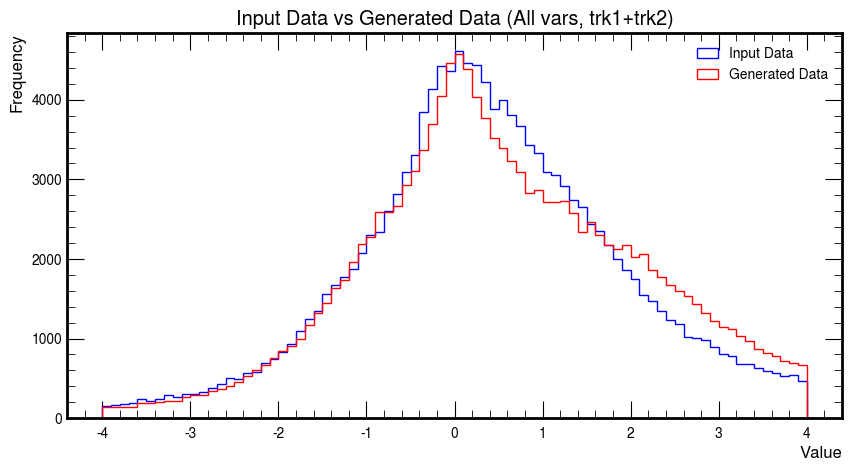

torch.Size([20000, 8])


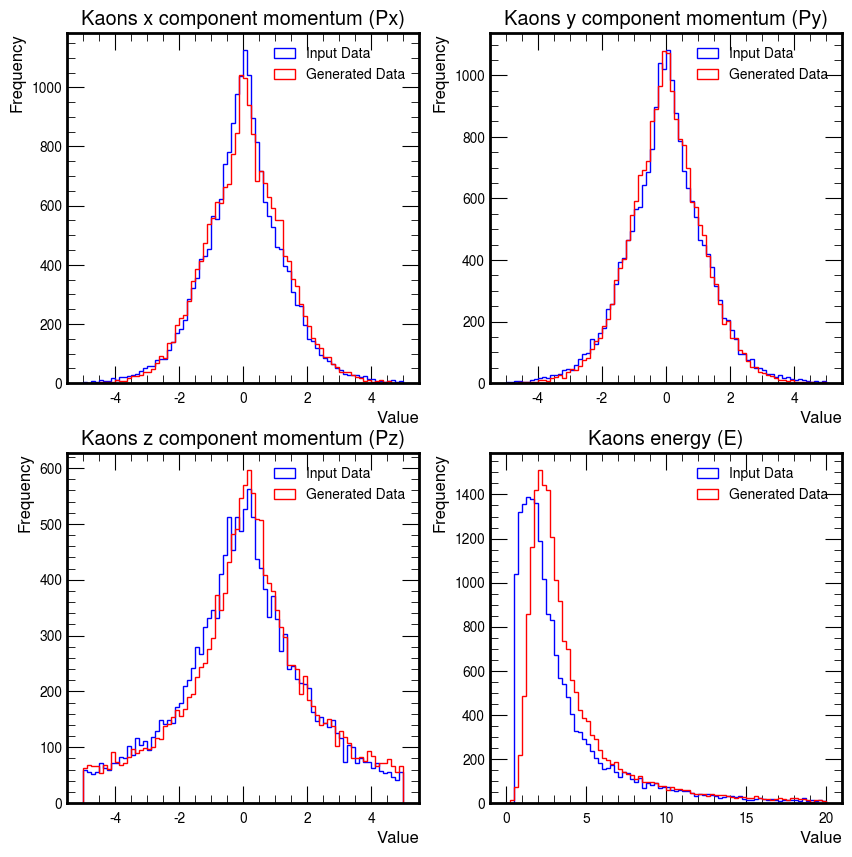

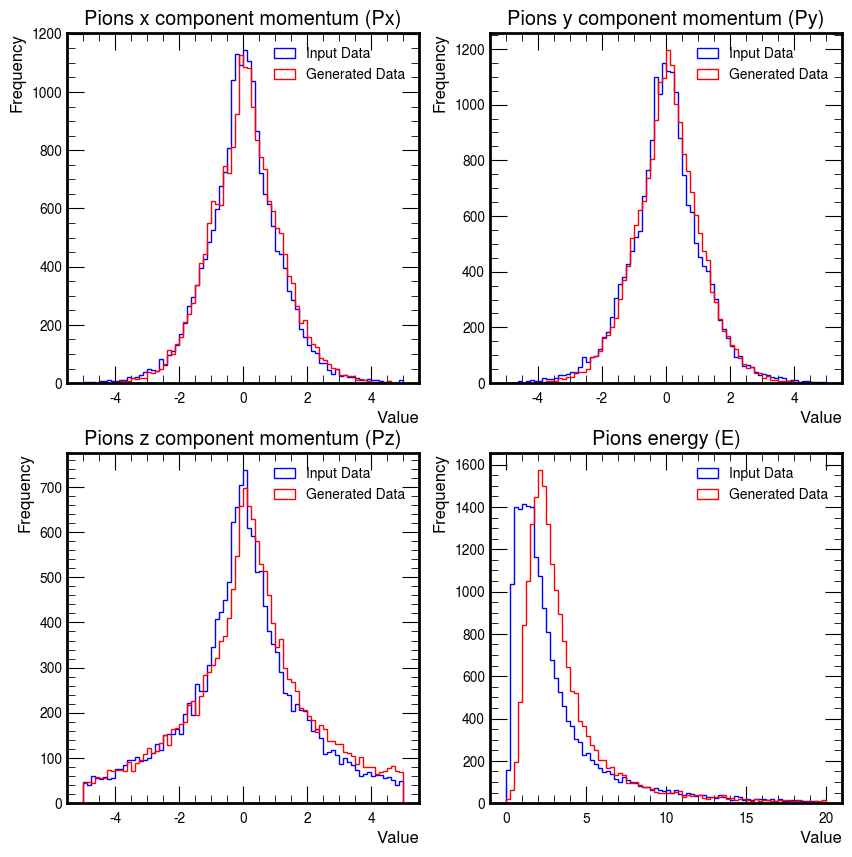

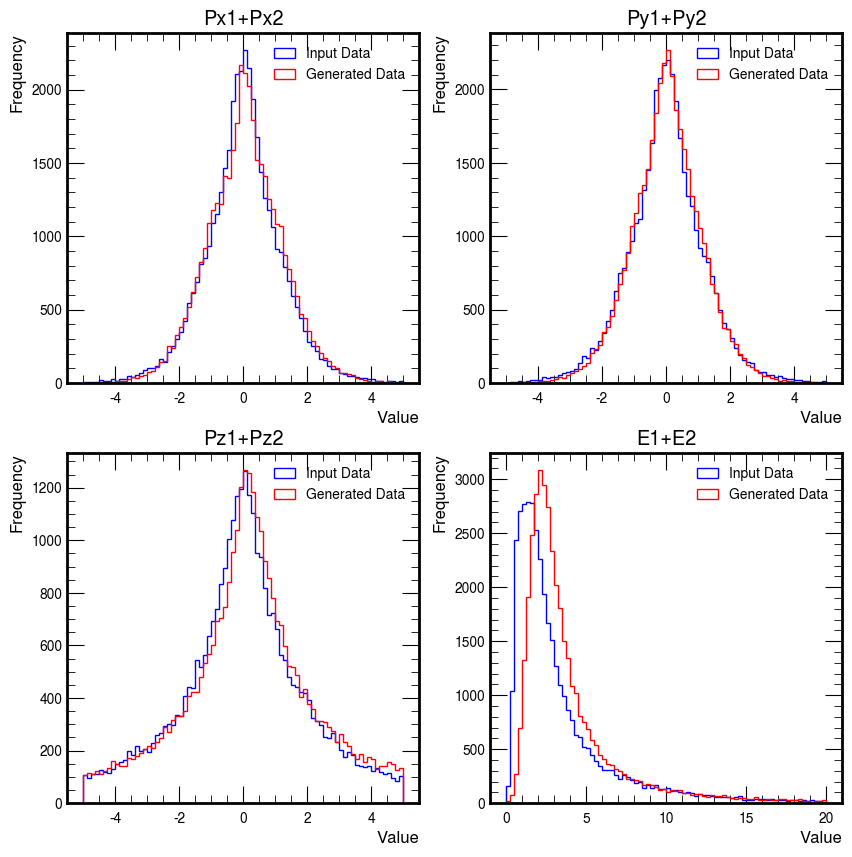

In [68]:
plt.figure(figsize=(10, 5))
plt.hist(tensor_data_denormalized.cpu().flatten(), bins=80, range=[-4, 4], histtype='step', color='blue', label='Input Data')
plt.hist(denormalize(generated_data).cpu().flatten(), bins=80, range=[-4, 4], histtype='step', color='red', label='Generated Data')
plt.title('Input Data vs Generated Data (All vars, trk1+trk2)')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()

print(tensor_data.size())
subplot_trk(tensor_data_denormalized.cpu(), denormalize(generated_data).cpu(), "trk1")
subplot_trk(tensor_data_denormalized.cpu(), denormalize(generated_data).cpu(), "trk2")
subplot_trk(tensor_data_denormalized.cpu(), denormalize(generated_data).cpu(), "both")

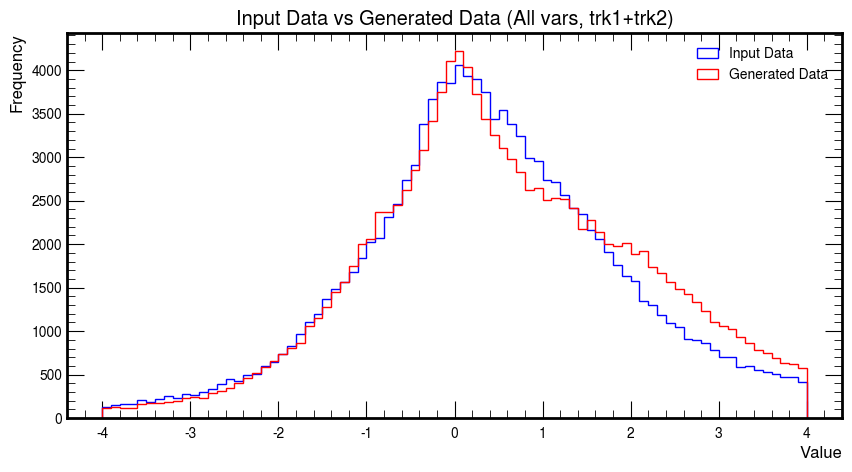

torch.Size([17676, 8])


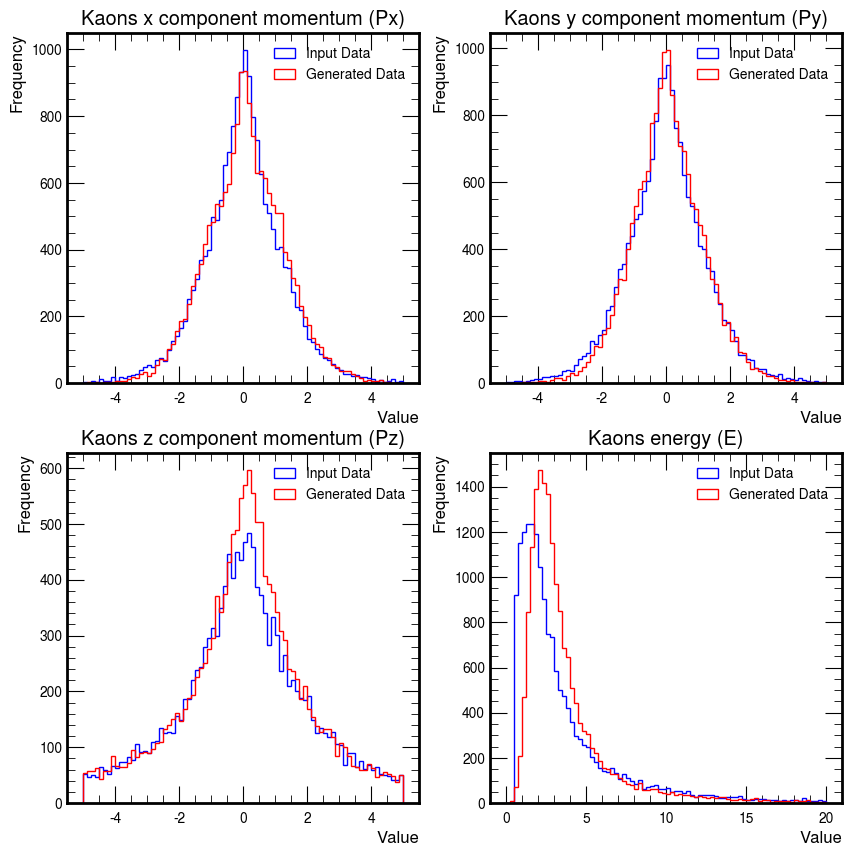

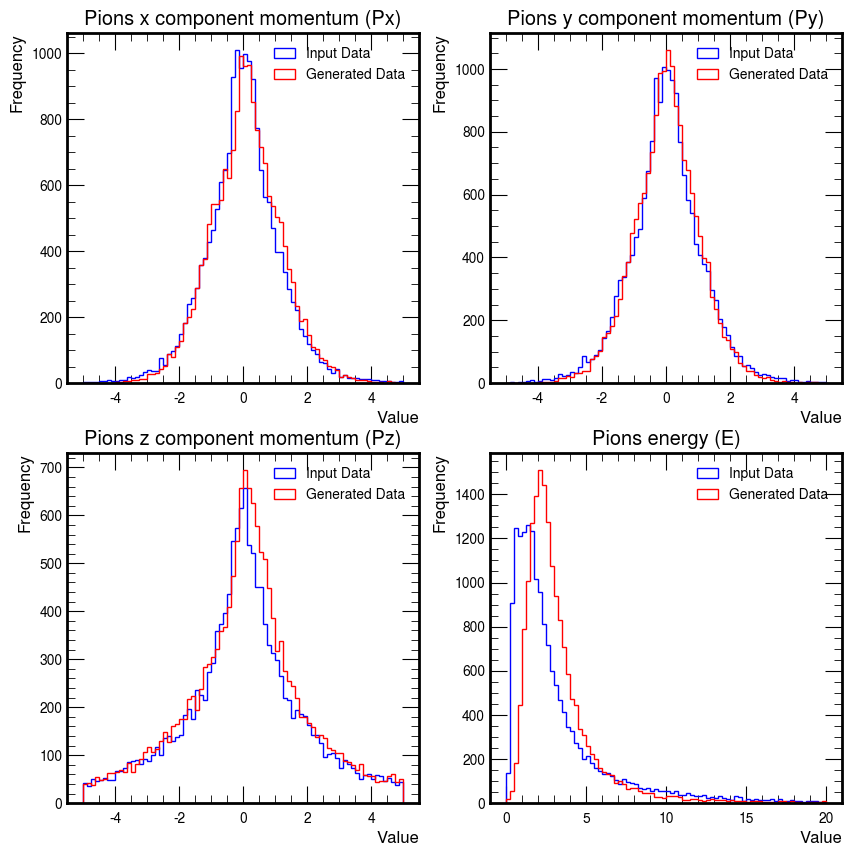

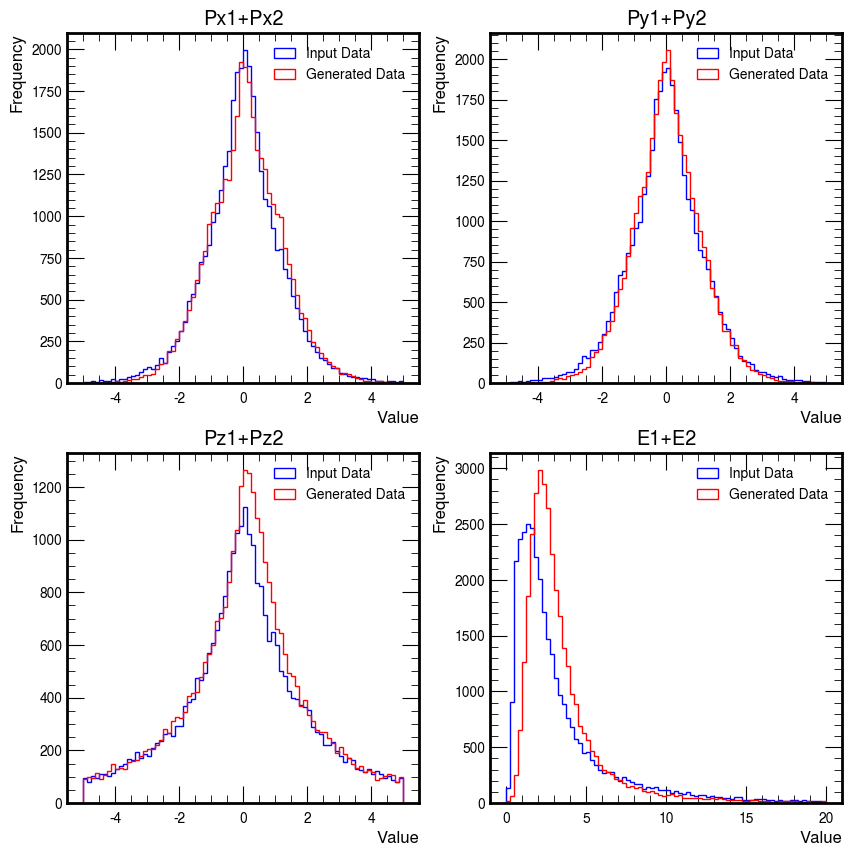

In [69]:
generated_data_denormalized = denormalize(generated_data)

generated_px = generated_data_denormalized[:, 0] + generated_data_denormalized[:, 1]
generated_py = generated_data_denormalized[:, 2] + generated_data_denormalized[:, 3]
generated_pz = generated_data_denormalized[:, 4] + generated_data_denormalized[:, 5]
generated_E = generated_data_denormalized[:, 6] + generated_data_denormalized[:, 7]


mass2 = generated_E**2 - generated_px**2 - generated_py**2 - generated_pz**2
mass_mask = mass2 > 0

energies_mask = ((generated_data_denormalized[:, 6] > 0) & (generated_data_denormalized[:, 7] > 0))
physical_mask = (mass_mask & energies_mask)
filtered_generated_data = generated_data_denormalized[physical_mask]
filtered_tensor_data_denormalized = tensor_data_denormalized[physical_mask]

plt.figure(figsize=(10, 5))
plt.hist(filtered_tensor_data_denormalized.cpu().flatten(), bins=80, range=[-4, 4], histtype='step', color='blue', label='Input Data')
plt.hist(filtered_generated_data.cpu().flatten(), bins=80, range=[-4, 4], histtype='step', color='red', label='Generated Data')
plt.title('Input Data vs Generated Data (All vars, trk1+trk2)')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()

print(filtered_tensor_data_denormalized.size())
subplot_trk(filtered_tensor_data_denormalized.cpu(), filtered_generated_data.cpu(), "trk1")
subplot_trk(filtered_tensor_data_denormalized.cpu(), filtered_generated_data.cpu(), "trk2")
subplot_trk(filtered_tensor_data_denormalized.cpu(), filtered_generated_data.cpu(), "both")

Abaixo, é rodado um teste de Kolmogorov-Smirnov para analisar a proximidade dos dois hitogramas em cada gráfico (apenas para as distribuições desnormalizadas). Uma das métricas de interesse é o p-valor.

P-Valor Significativo: um p-valor abaixo de 0.05 é frequentemente considerado significativo, o que indica que a hipótese nula (de que as distribuições são iguais) pode ser rejeitada.

P-Valor Não Significativo: Um p-valor acima de 0.05 geralmente sugere que não há evidência suficiente para rejeitar a hipótese nula. Valores como 0.10, 0.15, ou mais altos são interpretados como indicando uma falta de diferença significativa entre as distribuições.

P-Valor > 0.05: Indica que não há uma diferença significativa entre as distribuições comparadas. Esse é um bom sinal, sugerindo que as distribuições dos dados gerados ou reconstruídos são semelhantes aos dados reais.

P-Valor > 0.10 ou 0.15: Indica uma forte semelhança entre as distribuições, o que é ótimo.

In [70]:
import scipy.stats as stats
# Teste de Kolmogorov-Smirnov
train_recon_ks = stats.ks_2samp(x_train.cpu().flatten(), recon_train.cpu().flatten())
test_recon_ks = stats.ks_2samp(x_test.cpu().flatten(), recon_test.cpu().flatten())
input_generated_ks = stats.ks_2samp(tensor_data.cpu().flatten(), generated_data.cpu().flatten())

print(f"KS test for Train vs. Reconstructed Train: statistic={train_recon_ks.statistic}, p-value={train_recon_ks.pvalue}")
print(f"KS test for Test vs. Reconstructed Test: statistic={test_recon_ks.statistic}, p-value={test_recon_ks.pvalue}")
print(f"KS test for Input vs. Generated: statistic={input_generated_ks.statistic}, p-value={input_generated_ks.pvalue}")

KS test for Train vs. Reconstructed Train: statistic=0.057520833333333354, p-value=1.731488954126987e-138
KS test for Test vs. Reconstructed Test: statistic=0.057968749999999986, p-value=3.543024031553819e-47
KS test for Input vs. Generated: statistic=0.05389375000000002, p-value=2.126412007421503e-202


In [71]:
print(mass_func(generated_data_denormalized).mean())
print(torch.sqrt(torch.clamp(mass_func(generated_data_denormalized).mean(), min=0.0)))  #  1.8648 

tensor(10.6225, device='cuda:0')
tensor(3.2592, device='cuda:0')


In [72]:
wasserstein_distance(tensor_data.cpu().numpy().flatten(), generated_data.cpu().numpy().flatten())

np.float64(0.07742815712899451)

In [73]:
# Comparação correta — test set vs gerado condicionado no test set
input_generated_ks = stats.ks_2samp(
    x_test.cpu().numpy().flatten(),
    generated_data.cpu().numpy().flatten()
)

cols = ['px1','px2','py1','py2','pz1','pz2','E1','E2']
for i, name in enumerate(cols):
    w = wasserstein_distance(
        x_test.cpu().numpy()[:, i],
        generated_data.cpu().numpy()[:, i]
    )
    print(f"  {name}: {w:.4f}")

  px1: 0.0660
  px2: 0.0620
  py1: 0.0437
  py2: 0.0798
  pz1: 0.1252
  pz2: 0.0936
  E1: 0.1444
  E2: 0.1076
